<a href="https://colab.research.google.com/github/altheacamilet27/Lab7_Data_Visualization/blob/main/Lab7_Activity7_Camilet_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd

dataset_path = "spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path, encoding="utf-8")

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

print("Dataset loaded successfully!")
df.head(3)

Dataset loaded successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min,year
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767,2018.0
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883,2016.0
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667,2019.0


In [13]:
import numpy as np

# Clean text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert year to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=tempo_bins,
        labels=tempo_labels,
        right=False
    )
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("Data cleaning complete.")
print("Final row count:", len(df))

Data cleaning complete.
Final row count: 971


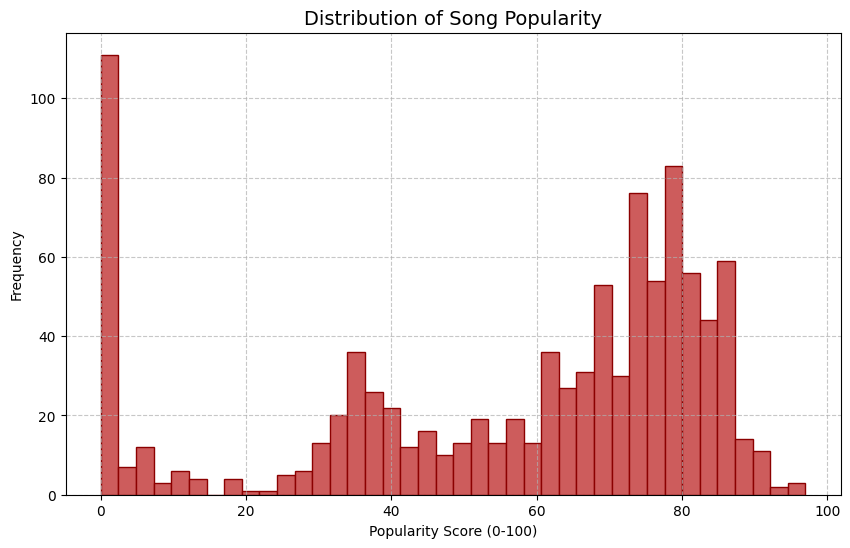

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')

plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2802/2481334427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


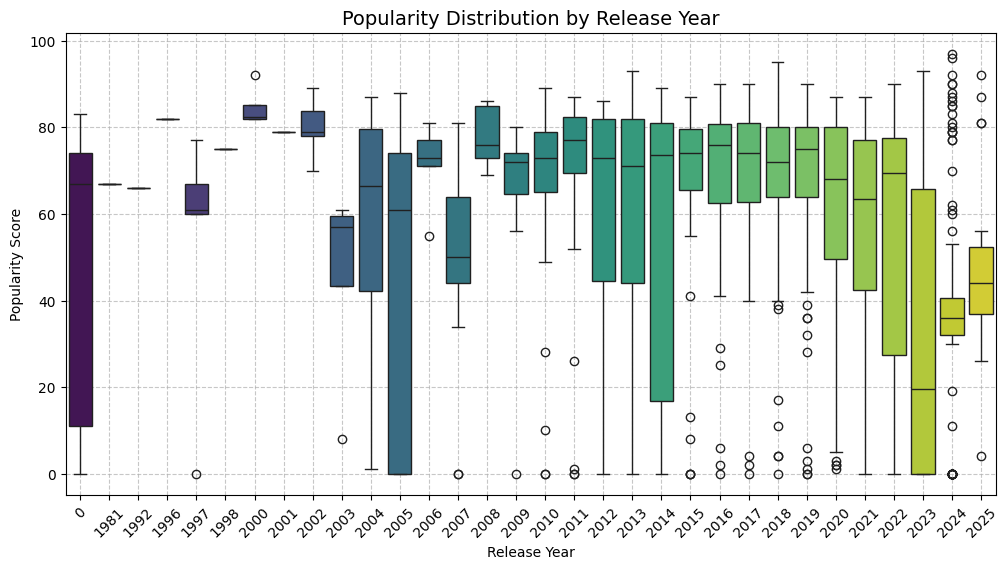

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(x='year', y='popularity', data=df, palette='viridis')

plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

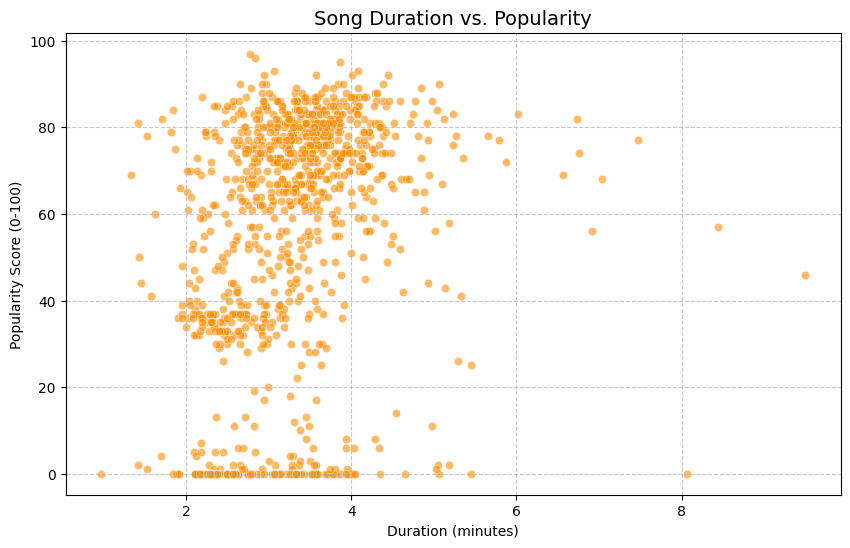

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df,
    alpha=0.6,
    color='darkorange'
)

plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

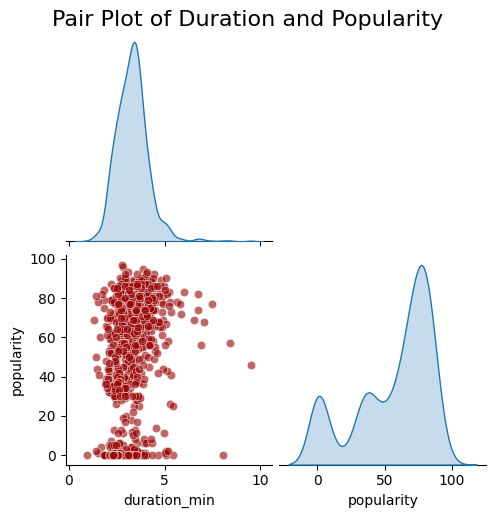

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only needed numeric columns
key_features = ['duration_min', 'popularity']

# Safety check (prevents crash if columns missing)
df_pair = df[key_features].dropna()

sns.pairplot(
    df_pair,
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)

plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)

plt.show()

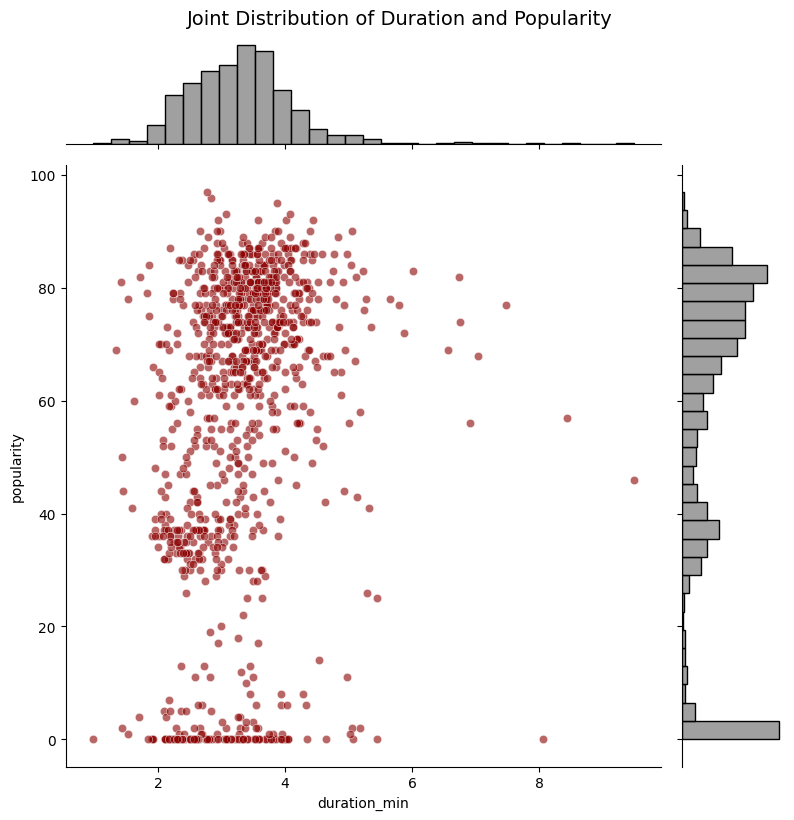

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean data
df_joint = df[['duration_min', 'popularity']].dropna()

sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df_joint,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)

plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)

plt.show()

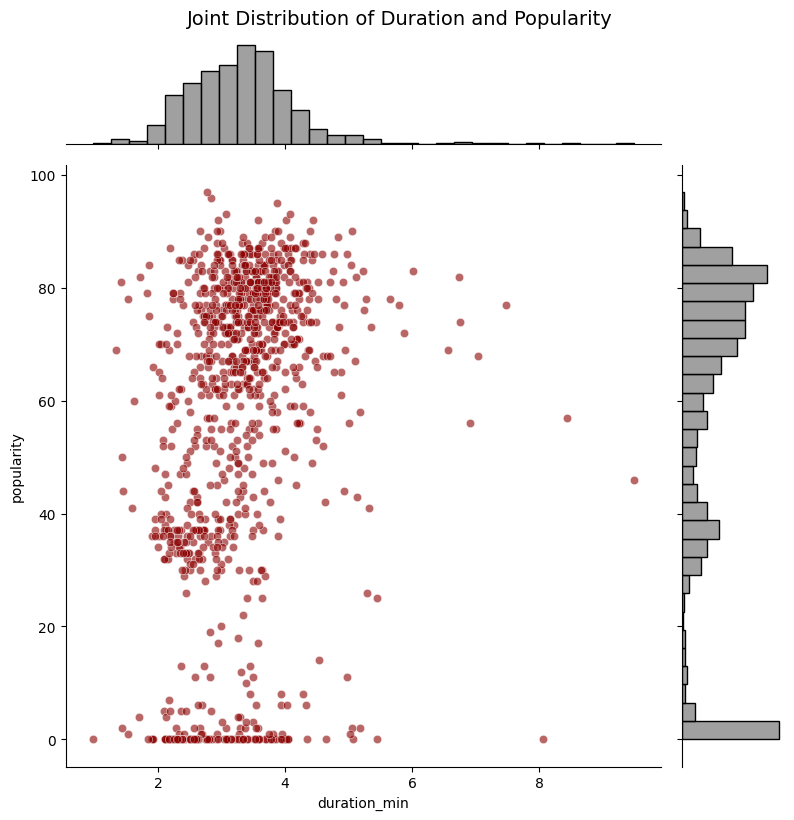

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use only needed columns and remove missing values
df_joint = df[['duration_min', 'popularity']].dropna()

# Create joint plot
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df_joint,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)

plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)

plt.show()

In [27]:
# Requirements:
# pip install matplotlib pillow pandas

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# --- Step 1: Load Dataset (FIXED PATH) ---
dataset_path = "spotify_dataset/spotify_top_1000_tracks.csv"

# If that file does not exist, fallback to downloaded file
if not os.path.exists(dataset_path):
    dataset_path = "spotify_top_1000_tracks (1).csv"

df = pd.read_csv(dataset_path)

# --- Step 2: Data Preparation ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# --- Step 3: Initialize the Figure ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')

ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()

# --- Step 4: Define Animation Function ---
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# --- Step 5: Create and Save Animation ---
ani = FuncAnimation(
    fig,
    animate,
    frames=len(yearly_popularity),
    interval=100,
    repeat=False
)

gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))

print(f"GIF saved successfully at: {gif_path}")

# --- Step 6: Open GIF ---
webbrowser.open(f"file://{gif_path}")

plt.close(fig)

GIF saved successfully at: /content/yearly_popularity_trend.gif
